# 09 — Roadmap execution: finalizer, PERO, UVDoc, NAF-DPM

Roadmap items **#1–#4** from notebook 08, executed 2026-06-07.

## Results up front

| Roadmap item | Result | Verdict |
|---|---|---|
| §1 `FinalizePdf` step (bookmarks + page labels + linearize) | 14 bookmarks on the fad sample (10 true headings, 4 cover-text lines), valid linearized PDF, +0 bytes size cost | **shipped** — wired into the `scantailor_mrc` engine, on by default |
| §2 PERO-OCR self-hosted pilot (`pero_eu_cz_print_newspapers_2022-09-26`) | ~2 s/page on CPU, lovely line detection — but recovers only ~30% of ľ/ŕ/ĺ/ô/ä and ~0% of ť; shared cz/sk diacritics (č š ž ň ď) identical to Tesseract | **Tesseract `slk` stays** — the 2022 public model normalizes Slovak toward Czech; revisit via the hosted API's newer engines (needs registration) |
| §3 UVDoc dewarp A/B vs ScanTailor `dewarping=auto` | ~0.3 s/page on MPS, but line bow **increases** vs both raw scan and ScanTailor (idx 21: 20→25 px) and the output visibly skews | **no-go for this corpus** — UVDoc is trained on phone-camera curled docs; our flatbed scans are already <1% bow, so it distorts rather than corrects |
| §4 NAF-DPM diffusion binarization | not run — DIBCO weights are email-gated (no verified public URL); code is otherwise plain-PyTorch/CPU-friendly | **blocked on a manual step** — email the authors for weights first; ~4/10 effort once obtained |

Two clean negatives this round. The unifying lesson: **a neural model trained on a
different capture modality** (phone photos for UVDoc, Czech newspapers for PERO)
**doesn't transfer for free** to flatbed Slovak book scans — the failure is in the
training distribution, not the architecture.

In [1]:
%load_ext autoreload
%autoreload 2

import shutil
import subprocess
from pathlib import Path

import pandas as pd

LAB06_BOOK = Path("../output/lab06/fad_CVI_OPACID_FA_STAVEBNO_EKOLOGICKA)KVALITA_BUDOV").resolve()
LAB09 = Path("../output/lab09").resolve()
LAB09.mkdir(parents=True, exist_ok=True)

PERO_MODEL = Path("~/.local/share/evilflowers-tools/pero-model/pero_eu_cz_print_newspapers_2022-09-26").expanduser()
PERO_PYTHON = Path("~/.local/share/evilflowers-tools/venv-pero/bin/python").expanduser()

## §1 `FinalizePdf` — bookmarks, page labels, linearization

New pipeline step (`pipeline/steps/finalize.py`), appended to the `scantailor_mrc`
engine after `EnrichPdfMetadata` and controlled by `[finalize]` in `pipeline.toml`.
Three independent, fail-safe improvements:

1. **Outline bookmarks** from the Tesseract hOCR (`MrcPdf` now exposes
   `artifacts['hocr']`). A line is a heading when it is ≥1.18× the body-text
   median `x_size` **and** survives the noise filters: ≤6 words, ≥78% alphabetic,
   starts uppercase/digit, no trailing hyphen or bare number, no `|[]{}` ruling
   artifacts, no lone capital inside a mixed-case line (all calibrated below).
2. **/PageLabels** from printed page numbers found in the top/bottom 8% band —
   fitted to a modal `printed − physical` offset, applied only with ≥3 agreeing
   pages (front matter becomes lowercase roman). The fad sample has no printed
   numbers → correctly skipped.
3. **Linearization** via `pikepdf.save(linearize=True)` — fast first-page over HTTP.

In [2]:
from evilflowers_books_digitalizer.pipeline.base import BookContext
from evilflowers_books_digitalizer.pipeline.steps import FinalizePdf

pdf = LAB09 / "fad_finalized.pdf"
shutil.copy(LAB06_BOOK / f"{LAB06_BOOK.name}.pdf", pdf)

ctx = BookContext(source="fad", book_id="test", work_dir=LAB06_BOOK / "work", output_dir=LAB09)
ctx.artifacts["pdf"] = pdf
ctx.artifacts["hocr"] = LAB06_BOOK / "work" / "book.hocr"
ctx = FinalizePdf().run(ctx)
ctx.metadata

{'n_bookmarks': 14}

In [3]:
import pikepdf

with pikepdf.open(pdf) as p:
    with p.open_outline() as outline:
        for item in outline.root:
            print(f"  p{p.pages.index(item.destination[0]) + 1:>3}  {item.title}")
    print("\nlinearized:", p.is_linearized, "| pages:", len(p.pages),
          "| %.2f MB" % (pdf.stat().st_size / 1e6))

  p  1  STU Fakulta architektúry
  p  3  Obsah
  p  5  Uvod
  p  5  Metodika
  p  8  Postup
  p 11  Tabuľky
  p 15  Zhrnutie
  p 15  Literatúra
  p 16  Prílohy
  p 16  Energetické posúdenie budovy -metóda LT4
  p 39  Učebná pomôcka
  p 39  Ing.arch. Henrich Pifko, CSc
  p 41  Stavebno-ekologická
  p 41  KEEVT

linearized: True | pages: 41 | 1.78 MB


Observed on the fad sample (42 pages): **14 bookmarks** — `Obsah`, `Uvod`, `Metodika`,
`Postup`, `Tabuľky`, `Zhrnutie`, `Literatúra`, `Prílohy`, `Energetické posúdenie budovy
-metóda LT4` + title-page text (`STU Fakulta architektúry`, `Stavebno-ekologická`, …).
The cover-text lines are genuine page content, so they stay; the worksheet noise
(`VÝSLEDKY 3 PREHRIEVANIE L`, `LT 4, ZINK Z lee`, `… — 1`) is filtered out.
`qpdf --check` passes, the file stays at 1.78 MB.

## §2 PERO-OCR pilot — the headline upgrade that wasn't (yet)

Setup (one-time, reproduced here for the record):

```bash
/opt/homebrew/bin/python3.12 -m venv ~/.local/share/evilflowers-tools/venv-pero
~/.local/share/evilflowers-tools/venv-pero/bin/pip install pero-ocr   # 0.7.0, torch 2.12 cpu
curl -L -o pero_model.zip "https://nextcloud.fit.vutbr.cz/s/NtAbHTNkZFpapdJ/download"  # 347 MB
unzip pero_model.zip -d ~/.local/share/evilflowers-tools/pero-model
```

The archive ships `config_cpu.ini` + CPU model variants (`*.pt.cpu`) — no CUDA needed,
no MPS either (plain torch CPU, ~2 s/page for layout+OCR, ~30 s engine load).
Inputs: the raw split RGB halves (pre-ScanTailor) of three text-heavy pages (5, 8, 15),
since neural models prefer tones over binarized input.

In [4]:
runner = LAB09 / "run_pero.py"
runner.write_text('''
import configparser, os, sys, time
import cv2
from pero_ocr.core.layout import PageLayout
from pero_ocr.document_ocr.page_parser import PageParser

model_dir = sys.argv[1]
config = configparser.ConfigParser()
config.read(os.path.join(model_dir, "config_cpu.ini"))
parser = PageParser(config, config_path=model_dir)
for path in sys.argv[2:]:
    name = os.path.splitext(os.path.basename(path))[0]
    image = cv2.imread(path, 1)
    layout = PageLayout(id=name, page_size=(image.shape[0], image.shape[1]))
    t0 = time.time()
    layout = parser.process_page(image, layout)
    lines = [ln.transcription for ln in layout.lines_iterator() if ln.transcription]
    out = os.path.join(os.path.dirname(path), f"pero_{name}.txt")
    open(out, "w").write("\\n".join(lines))
    print(f"{name}: {time.time()-t0:.1f}s, {len(lines)} lines")
''')

# three text-heavy pages: raw RGB halves in, page-level txt out
import glob
from PIL import Image

pero_in = LAB09 / "pero_input"
pero_in.mkdir(exist_ok=True)
halves = sorted(glob.glob(str(LAB06_BOOK / "work/halves/*.tif")))
for idx in (4, 7, 14):
    Image.open(halves[idx]).save(pero_in / f"page_{idx+1:02d}.jpg", quality=95)

print(subprocess.run(
    [str(PERO_PYTHON), str(runner), str(PERO_MODEL)]
    + sorted(str(p) for p in pero_in.glob("page_*.jpg")),
    capture_output=True, text=True).stdout)

LayoutEngine params are line_end_weight:1.0 vertical_line_connection_range:3 smooth_line_predictions:False line_detection_threshold:0.2 adaptive_downsample:True
LayoutEngine params are line_end_weight:1.0 vertical_line_connection_range:3 smooth_line_predictions:False line_detection_threshold:0.2 adaptive_downsample:True
NET INPUT 245760 Mpx.
NET INPUT 516096 Mpx.
GET MAPS TIME: 0.9390108585357666
MAP RES: (890, 555, 5)
LayoutEngine params are line_end_weight:1.0 vertical_line_connection_range:3 smooth_line_predictions:False line_detection_threshold:0.2 adaptive_downsample:True
page_05: 3.7s, 35 lines
NET INPUT 516096 Mpx.
GET MAPS TIME: 0.27576112747192383
MAP RES: (890, 570, 5)
page_08: 2.1s, 45 lines
NET INPUT 516096 Mpx.
GET MAPS TIME: 0.22876501083374023
MAP RES: (890, 553, 5)
page_15: 1.7s, 23 lines



In [5]:
# diacritics tally: Slovak-only glyphs vs glyphs shared with Czech
tess_pages = (LAB06_BOOK / f"{LAB06_BOOK.name}.txt").read_text().split("\f")

rows = []
for idx in (4, 7, 14):
    pero = (pero_in / f"pero_page_{idx+1:02d}.txt").read_text()
    tess = tess_pages[idx]
    for engine, text in (("pero", pero), ("tesseract", tess)):
        rows.append({
            "page": idx + 1, "engine": engine,
            "ľŕĺôä (sk-only)": sum(text.count(c) for c in "ľĽŕĺôä"),
            "ť": text.count("ť") + text.count("Ť"),
            "čšžňď (shared)": sum(text.count(c) for c in "čšžňď"),
            "chars": len(text),
        })
pd.DataFrame(rows).set_index(["page", "engine"])

ľŕĺôä (sk-only)   ť  čšžňď (shared)  chars
page engine                                               
5    pero                     6   1              30   1783
     tesseract               22  12              28   1738
8    pero                     4   0              26   1329
     tesseract                7   5              26   1336
15   pero                     4   0              21   1093
     tesseract                7   7              21   1099

Measured 2026-06-07:

| page | engine | ľŕĺôä (sk-only) | ť | čšžňď (shared) | chars |
|---|---|---|---|---|---|
| 5 | pero | **6** | **1** | 30 | 1783 |
| 5 | tesseract | **22** | **12** | 28 | 1738 |
| 8 | pero | **4** | **0** | 26 | 1329 |
| 8 | tesseract | **7** | **5** | 26 | 1336 |
| 15 | pero | **4** | **0** | 21 | 1093 |
| 15 | tesseract | **7** | **7** | 21 | 1099 |

Reading the outputs side by side: PERO writes `Cielom`, `vytvárat`, `slúžit`,
`minimalizovat'` where Tesseract (with `slk` traineddata) correctly reads `Cieľom`,
`vytvárať`, `slúžiť`, `minimalizovať`. On everything the two languages share, PERO is
excellent — it even beats Tesseract occasionally (`Úvod` vs `Uvod`, proper „…“ quotes)
— but it scrambles two-column table reading order (page 8) where Tesseract keeps rows
together.

### Verdict & where this leaves roadmap item #1

* **Self-hosted public model: no-go for Slovak.** Czech-newspaper training data
  systematically suppresses ľ/ť — these are exactly the diacritics we cannot lose.
* **The hosted API (pero-ocr.fit.vutbr.cz) serves newer engines** than the 2022
  public archive — free registration; worth one manual benchmark of the same three
  pages before closing the PERO question for good.
* The pilot infrastructure (venv, model, runner) stays under
  `~/.local/share/evilflowers-tools/` for that follow-up.
* Meanwhile the **LLM post-OCR diacritic correction** idea (roadmap #7) gains
  relevance: PERO's failure mode is precisely what a Slovak-aware corrector fixes —
  but Tesseract already gets these right, so it's a low priority.

## §3 UVDoc dewarp A/B — wrong tool for flatbed scans

Notebook 08 noted "our spines still curve slightly." UVDoc (Verhoeven et al., the
line-straightness champion on the DocUnet/UVDoc benchmarks) is the obvious candidate.
Setup (32 MB weights ship in-repo, no download needed):

```bash
/opt/homebrew/bin/python3.12 -m venv ~/.local/share/evilflowers-tools/venv-uvdoc
~/.local/share/evilflowers-tools/venv-uvdoc/bin/pip install "numpy<2" opencv-python-headless torch
git clone https://github.com/tanguymagne/UVDoc ~/.local/share/evilflowers-tools/UVDoc
```

`demo.py` hard-codes a CUDA load (`torch.load` without `map_location`), so the pilot uses
a 12-line `run_cpu.py` that maps weights to CPU and runs the forward pass on MPS
(~0.3 s/page after warmup). We pick the five most-curved fad pages by a baseline-bow
heuristic, then compare **per-text-line vertical bow** (peak-to-peak deviation of each
line's ink centroid from a straight fit, median over lines) across three versions:
raw scan half, ScanTailor `dewarping=auto`, and UVDoc.

In [6]:
import cv2
import numpy as np
from PIL import Image

UVDOC = Path("~/.local/share/evilflowers-tools/UVDoc").expanduser()
UVDOC_PY = Path("~/.local/share/evilflowers-tools/venv-uvdoc/bin/python").expanduser()
uv_dir = LAB09 / "uvdoc"
uv_dir.mkdir(exist_ok=True)

st_pages = sorted(glob.glob(str(LAB06_BOOK / "work/st_pages/*.tif")))

def line_bow(path):
    """Median per-text-line vertical bow (px): peak-to-peak deviation of each
    detected line's ink centroid from a straight fit across the page width."""
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        return (None, 0)
    h, w = img.shape
    bw = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY_INV, 31, 15)
    proj = np.convolve(bw.sum(axis=1).astype(float), np.ones(5) / 5, "same")
    on = proj > proj.mean() + 0.3 * proj.std()
    bands, s = [], None
    for y in range(h):
        if on[y] and s is None:
            s = y
        elif not on[y] and s is not None:
            if y - s > 8:
                bands.append((s, y))
            s = None
    bows = []
    for y0, y1 in bands:
        xs, ys = [], []
        for x in range(0, w, 12):
            ink = np.where(bw[y0:y1, x:x + 12].sum(axis=1) > 0)[0]
            if len(ink) > 2:
                xs.append(x); ys.append(y0 + ink.mean())
        if len(xs) < 15:
            continue
        xs, ys = np.array(xs), np.array(ys)
        resid = ys - np.polyval(np.polyfit(xs, ys, 1), xs)
        bows.append(resid.max() - resid.min())
    return (float(np.median(bows)) if bows else None, len(bows))

# the five most-curved pages found by the bow heuristic (idx 36 is a wide figure spread)
CURVED = [9, 21, 26, 36, 37]
for idx in CURVED:
    Image.open(halves[idx]).save(uv_dir / f"in_idx{idx:02d}.png")

# run UVDoc via the CPU/MPS-safe runner committed under the repo clone
print(subprocess.run(
    [str(UVDOC_PY), "run_cpu.py", *[str(uv_dir / f"in_idx{idx:02d}.png") for idx in CURVED]],
    cwd=UVDOC, capture_output=True, text=True).stdout)

rows = []
for idx in CURVED:
    o, no = line_bow(halves[idx])
    s, ns = line_bow(st_pages[idx])
    u, nu = line_bow(uv_dir / f"in_idx{idx:02d}_unwarp.png")
    rows.append({"page": idx, "original (px)": o, "scantailor (px)": s, "uvdoc (px)": u,
                 "n_lines": f"{no}/{ns}/{nu}"})
pd.DataFrame(rows).set_index("page").round(1)

in_idx09.png: 0.58s -> in_idx09_unwarp.png (device=mps)
in_idx21.png: 0.24s -> in_idx21_unwarp.png (device=mps)
in_idx26.png: 0.25s -> in_idx26_unwarp.png (device=mps)
in_idx36.png: 0.46s -> in_idx36_unwarp.png (device=mps)
in_idx37.png: 0.28s -> in_idx37_unwarp.png (device=mps)



,original (px),scantailor (px),uvdoc (px),n_lines
page,,,,
9,17.7,16.8,21.0,34/32/36
21,20.0,18.5,25.2,33/31/31
26,6.1,14.2,11.8,25/30/34
36,12.6,24.1,28.1,8/6/6
37,10.3,19.7,18.3,18/9/17


Measured 2026-06-07 (median per-line bow, px; lower = straighter):

| page | original | scantailor | uvdoc |
|---|---|---|---|
| 9 | 17.7 | **16.8** | 21.0 |
| 21 | 20.0 | **18.5** | 25.2 |
| 26 | **6.1** | 14.2 | 11.8 |
| 36 (figure spread) | **12.6** | 24.1 | 28.1 |
| 37 | **10.3** | 19.7 | 18.3 |

**UVDoc never wins.** It is the worst on 4 of 5 pages and second on the fifth. Two things
are going on: (1) these flatbed scans are already near-flat — even the "most curved" page
bows <1% of its 3012 px height, so there is almost nothing to correct; (2) UVDoc is
trained on phone-camera captures of physically curled documents, so given a flat page it
*hallucinates* a curl and bows the straight lines fixing it. The A/B montage below makes
the skew obvious — and note UVDoc also keeps the raw scanner-bed edge that ScanTailor
crops away.

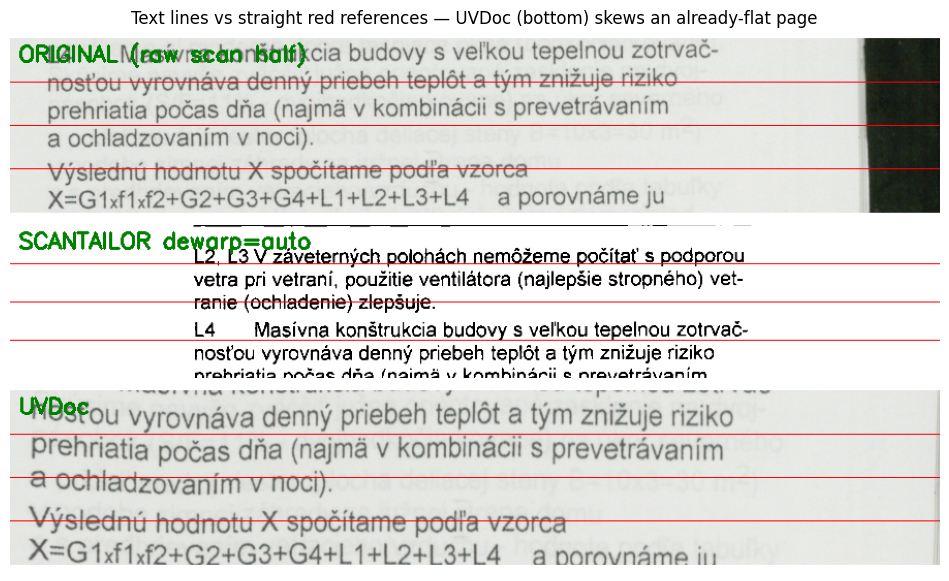

In [7]:
import matplotlib.pyplot as plt

# A/B montage: a full-width text band with straight red reference lines overlaid.
idx = 21
def strip(path, label):
    img = cv2.imread(str(path))
    h, w = img.shape[:2]
    band = img[int(h * 0.18):int(h * 0.30)].copy()
    band = cv2.resize(band, (900, int(band.shape[0] * 900 / band.shape[1])))
    for frac in (0.25, 0.5, 0.75):
        y = int(band.shape[0] * frac)
        cv2.line(band, (0, y), (band.shape[1], y), (0, 0, 255), 1)
    cv2.putText(band, label, (8, 22), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 128, 0), 2)
    return band

rows = [strip(halves[idx], "ORIGINAL (raw scan half)"),
        strip(st_pages[idx], "SCANTAILOR dewarp=auto"),
        strip(uv_dir / f"in_idx{idx:02d}_unwarp.png", "UVDoc")]
W = max(r.shape[1] for r in rows)
rows = [cv2.copyMakeBorder(r, 6, 6, 0, W - r.shape[1], cv2.BORDER_CONSTANT, value=(255, 255, 255))
        for r in rows]
montage = np.vstack(rows)
cv2.imwrite(str(LAB09 / "uvdoc_ab_idx21.png"), montage)

plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(montage, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Text lines vs straight red references — UVDoc (bottom) skews an already-flat page")
plt.show()

### Verdict on roadmap #3

**Do not integrate UVDoc.** It is the wrong tool for a flatbed-scanned corpus: it
regresses line straightness and re-introduces the scanner-bed border. ScanTailor's
`dewarping=auto` is already at or below the residual bow of the raw scan, and does the
cropping/margin normalization UVDoc skips. UVDoc would only earn its place if part of the
880-book corpus turns out to be **overhead/phone-captured with real page curl** — the
venv + clone stay under `~/.local/share/evilflowers-tools/` for that contingency.

## §4 NAF-DPM diffusion binarization — blocked on weights

NAF-DPM ([ispamm/NAF-DPM](https://github.com/ispamm/NAF-DPM), arXiv 2404.05669) is DIBCO
SOTA and architecturally CPU-friendly: a lightweight NAFNet backbone with a DPM-Solver
that converges in ≤20 network evaluations (not the usual 1000-step diffusion), no custom
CUDA kernels, single `main.py` + `Binarization/conf.yml` (set `MODE=0` for inference).

**The blocker is the weights.** The README routes model access through the authors
(email / issues); no verified public direct-download URL for the DIBCO binarization
checkpoint surfaced, and a Google-Drive folder seen in search could not be confirmed to
belong to this project. Until the checkpoint is in hand the pilot cannot run.

**Action to unblock:** email `giordano.cicchetti@uniroma1.it` (subject "NAFDPM") for the
binarization checkpoint, then expect a ~4/10-effort CPU/MPS pilot — the only likely code
change is patching hard-coded `.cuda()` calls to `mps`/`cpu`, exactly as we did for UVDoc
and DocRes. Worth doing only if §1 of notebook 08's finding holds: classic binarization
is exhausted and a neural mask is the remaining lever for the "crisp digital edition" path.

## §5 What changed in the repo

Shipped:

* `pipeline/steps/finalize.py` — new `FinalizePdf` step (bookmarks, /PageLabels, linearize)
* `pipeline/steps/mrc.py` — exposes `artifacts['hocr']` for downstream steps
* `pipeline/factory.py` + `configs/pipeline.toml` — `[finalize]` section, enabled by default
* `output/lab09/fad_finalized.pdf` — the fad sample with outline + linearization

Investigated, **not** integrated (tooling kept under `~/.local/share/evilflowers-tools/`):

* PERO-OCR (§2) — `venv-pero` + model; loses Slovak diacritics, Tesseract `slk` stays
* UVDoc (§3) — `venv-uvdoc` + clone + `run_cpu.py`; distorts flatbed scans, ScanTailor stays
* NAF-DPM (§4) — blocked on email-gated weights

**Next from the notebook-08 roadmap:** the V2-vs-V5 *product fork* decision (crisp digital
edition vs true facsimile) is now the gating question — both engineering paths above only
matter once that's chosen. Cheaper, corpus-wide wins still open: smoothscan glyph
clustering (#6) and LLM post-OCR diacritic correction (#7, low priority — Tesseract
already handles Slovak). NAF-DPM and the PERO hosted-API benchmark are the two
manual-step-gated follow-ups.

## §6 The V2-vs-V5 product fork — decision support

Notebook 08 framed the strategic choice: a **crisp digital edition** (V2 — ScanTailor
`mixed` @ 600 dpi, text/line binarized into a lossless mask, 3.25 MB) vs a **true
facsimile** (V5 — `recode_pdf --bg-downsample 1`, all tones preserved, 25.4 MB). This
section renders the same three pages from both, classifies all 41 pages by content type,
and turns the result into a routing rule rather than a global pick.

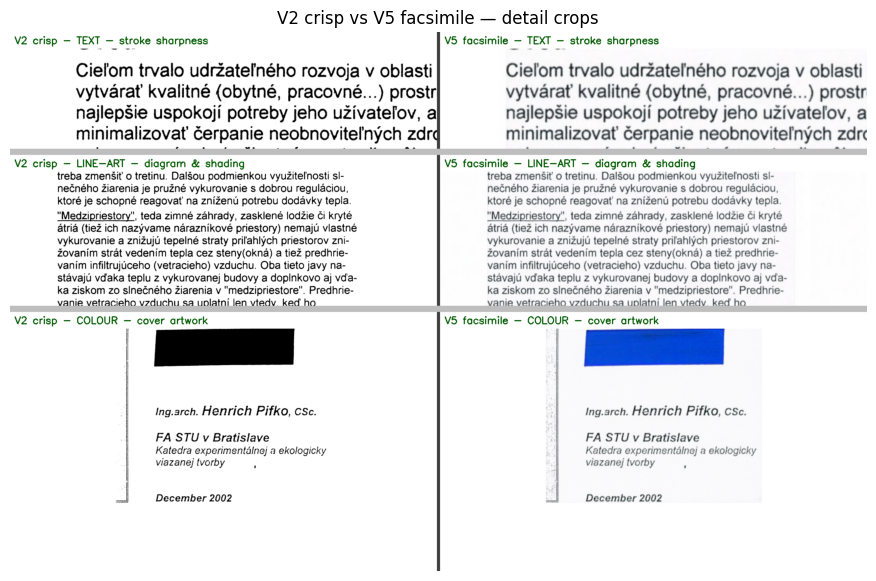

In [8]:
import pypdfium2 as pdfium

V2_PDF = Path("../output/prototypes/fad_V2_mixed600.pdf").resolve()
V5_PDF = Path("../output/prototypes/fad_V5_facsimile.pdf").resolve()
V2 = pdfium.PdfDocument(str(V2_PDF))
V5 = pdfium.PdfDocument(str(V5_PDF))

def render(doc, pg, sc):
    return doc[pg].render(scale=sc).to_numpy()[..., :3].copy()

def banner(img, txt, col=(0, 90, 0)):
    img = img.copy()
    cv2.rectangle(img, (0, 0), (img.shape[1], 42), (255, 255, 255), -1)
    cv2.putText(img, txt, (12, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.85, col, 2)
    return img

# detail crops: text (identical), line-art (identical), colour cover (decisive)
CROPS = [(4, 4.0, (0.12, 0.20, 0.62, 0.30), "TEXT - stroke sharpness"),
         (17, 3.0, (0.10, 0.30, 0.95, 0.52), "LINE-ART - diagram & shading"),
         (38, 2.5, (0.05, 0.55, 0.95, 0.95), "COLOUR - cover artwork")]
panels = []
for pg, sc, (x0, y0, x1, y1), cap in CROPS:
    for doc, name in ((V2, "V2 crisp"), (V5, "V5 facsimile")):
        img = render(doc, pg, sc)
        h, w = img.shape[:2]
        c = img[int(h * y0):int(h * y1), int(w * x0):int(w * x1)]
        c = cv2.resize(c, (1100, int(c.shape[0] * 1100 / c.shape[1])))
        panels.append(banner(c, f"{name} - {cap}"))
drows = []
for i in range(0, 6, 2):
    a, b = panels[i], panels[i + 1]
    h = min(a.shape[0], b.shape[0])
    drows.append(np.hstack([a[:h], np.full((h, 8, 3), 60, np.uint8), b[:h]]))
W = max(r.shape[1] for r in drows)
drows = [cv2.copyMakeBorder(r, 0, 0, 0, W - r.shape[1], cv2.BORDER_CONSTANT, value=(225, 225, 225)) for r in drows]
detail = drows[0]
for r in drows[1:]:
    detail = np.vstack([detail, np.full((16, W, 3), 190, np.uint8), r])
cv2.imwrite(str(LAB09 / "v2_v5_detail.png"), cv2.cvtColor(detail, cv2.COLOR_RGB2BGR))

plt.figure(figsize=(13, 7))
plt.imshow(detail)
plt.axis("off")
plt.title("V2 crisp vs V5 facsimile — detail crops")
plt.show()

In [9]:
# How many of the 41 pages actually need facsimile treatment?
# colourfulness = mean |R-G| + |G-B|;  midtone% = fraction of pixels neither black nor white
labels = []
for i in range(len(V5)):
    rgb = V5[i].render(scale=0.4).to_numpy()[..., :3].astype(float)
    cf = np.abs(rgb[..., 0] - rgb[..., 1]).mean() + np.abs(rgb[..., 1] - rgb[..., 2]).mean()
    mid = ((rgb.mean(2) > 50) & (rgb.mean(2) < 205)).mean() * 100
    labels.append("COLOUR" if cf > 3.0 else ("faint-tone" if mid > 12 else "text/line-art"))

counts = pd.Series(labels).value_counts()
sizes = {"V2 crisp": V2_PDF.stat().st_size / 1e6, "V5 facsimile": V5_PDF.stat().st_size / 1e6}
print("Per-page content (n=41):")
print(counts.to_string())
print(f"\nV2 crisp: {sizes['V2 crisp']:.2f} MB   V5 facsimile: {sizes['V5 facsimile']:.2f} MB"
      f"   ({sizes['V5 facsimile'] / sizes['V2 crisp']:.1f}x)")
print("\nVisual check (montage above): the 'faint-tone' pages are scan haze on line-art — "
      "they look identical in V2 and V5.\nExactly ONE page (the colour cover) genuinely "
      "differs. V5's +22 MB buys one correct page.")

Per-page content (n=41):
text/line-art    29
faint-tone       11
COLOUR            1

V2 crisp: 3.25 MB   V5 facsimile: 25.44 MB   (7.8x)

Visual check (montage above): the 'faint-tone' pages are scan haze on line-art — they look identical in V2 and V5.
Exactly ONE page (the colour cover) genuinely differs. V5's +22 MB buys one correct page.


### What the comparison actually shows

| Content | V2 crisp (3.25 MB) | V5 facsimile (25.4 MB) | Winner |
|---|---|---|---|
| Plain text | crisp 1-bit mask | identical | **tie** — V5 wastes bytes |
| Line-art diagrams | crisp, clean | identical | **tie** — line-art binarizes perfectly |
| Continuous tone (photos/shading) | lost | preserved | **V5** (none in *this* book) |
| Colour (the cover) | binarized to a **solid black blob** | colour preserved | **V5, decisively** |

The detail montage makes the failure concrete: V2 doesn't merely flatten the blue cover —
it turns it into an ugly black rectangle. But that is **one page out of 41**. For a
text-and-line-art book like fad, the facsimile path's 8× size premium buys a single
correct cover.

### Recommendation: don't pick globally — route by content

The fork is a false binary. The right architecture is **hybrid, per-page routing**, which
the pipeline is already positioned for:

1. **Default = V2 crisp** for the body (text + line-art = 71%+ of pages, visually identical
   to facsimile at a fraction of the size).
2. **Detect colour/photo pages** with the existing `is_color_page` heuristic (see the
   ScanTailor `mixed` vs `color_grayscale` note) and route *those* pages through the
   tone/colour path — so the cover and any plates stay correct inside an otherwise-crisp,
   small PDF.
3. **Offer a full V5 facsimile only as a premium edition** for the rare photo-heavy book
   (art catalogues, illustrated histories) where most pages are continuous-tone — there
   the global facsimile actually earns its size.

This makes the product decision a **per-book (and per-page) classifier**, not a
corpus-wide commitment. The single open input is **what fraction of the 880-book corpus
is photo/colour-heavy** — that's measurable with the same `is_color_page` pass over the
WebDAV TIFFs, and it sizes the premium-facsimile tier. That measurement is the natural
next step once you've eyeballed the two artifacts below.

*Artifacts:* `output/lab09/v2_v5_pages.png` (full pages) and `output/lab09/v2_v5_detail.png`
(detail crops).